In [1]:
# 9.6 Q1 - Hand-Written Digit Recognition with KNN

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, accuracy_score,
    classification_report)

In [3]:
digits = load_digits()
X = digits.data
y = digits.target
print("X shape:", X.shape, "y shape:", y.shape)
print("Number of classes:", len(np.unique(y)))
print("Image size: 8x8 = 64 pixels per sample")

X shape: (1797, 64) y shape: (1797,)
Number of classes: 10
Image size: 8x8 = 64 pixels per sample


In [4]:
# Visualise first 10 digits

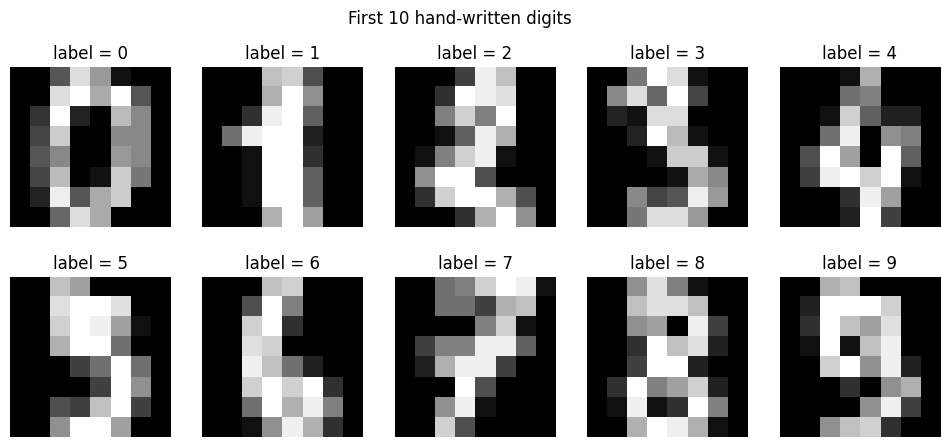

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title('label = ' + str(digits.target[i]))
    ax.axis('off')
plt.suptitle('First 10 hand-written digits')
plt.show()

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
sc = StandardScaler()
X_train_s = sc.fit_transform(X_train)
X_test_s  = sc.transform(X_test)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (1257, 64) Test: (540, 64)


In [7]:
# Sweep K = 1, 3, 5, 7, 9

In [8]:
results = []
for k in [1, 3, 5, 7, 9]:
    m = KNeighborsClassifier(n_neighbors=k, metric='minkowski', p=2)
    m.fit(X_train_s, y_train)
    acc = accuracy_score(y_test, m.predict(X_test_s))
    results.append({'K': k, 'Accuracy': acc})
    print("K =", k, ": accuracy =", acc)

best_k = max(results, key=lambda r: r['Accuracy'])['K']
print()
print("Best K =", best_k)

K = 1 : accuracy = 0.9740740740740741
K = 3 : accuracy = 0.9722222222222222
K = 5 : accuracy = 0.9703703703703703
K = 7 : accuracy = 0.9685185185185186
K = 9 : accuracy = 0.9666666666666667

Best K = 1


In [9]:
# Train final model & evaluate

In [10]:
model = KNeighborsClassifier(n_neighbors=best_k, metric='minkowski', p=2)
model.fit(X_train_s, y_train)
y_pred = model.predict(X_test_s)

print("Accuracy (K=" + str(best_k) + "):", accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))

Accuracy (K=1): 0.9740740740740741

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        54
           1       0.95      0.98      0.96        55
           2       0.98      0.96      0.97        53
           3       0.96      1.00      0.98        55
           4       0.96      0.96      0.96        54
           5       1.00      0.98      0.99        55
           6       0.98      1.00      0.99        54
           7       0.96      1.00      0.98        54
           8       0.96      0.90      0.93        52
           9       0.98      0.94      0.96        54

    accuracy                           0.97       540
   macro avg       0.97      0.97      0.97       540
weighted avg       0.97      0.97      0.97       540



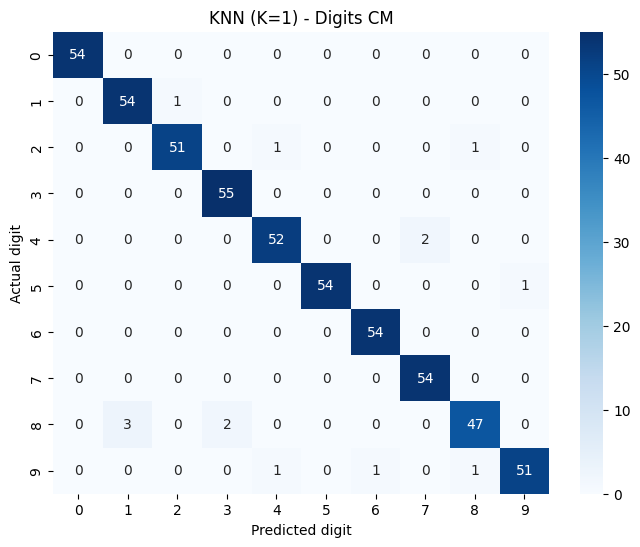

In [11]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted digit')
plt.ylabel('Actual digit')
plt.title('KNN (K=' + str(best_k) + ') - Digits CM')
plt.show()

In [12]:
# Misclassified examples

Total misclassifications: 14


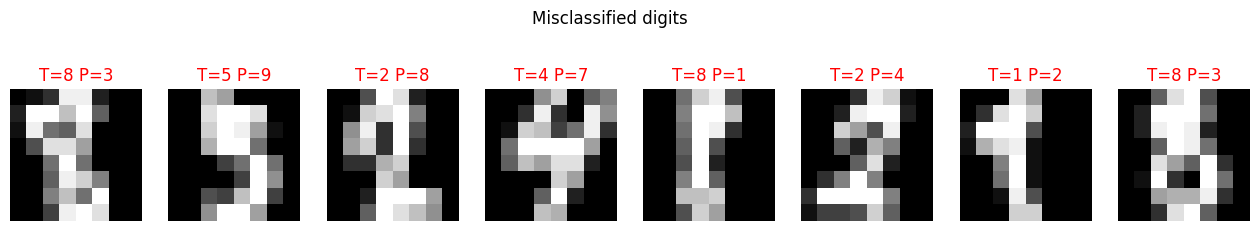

In [13]:
wrong = np.where(y_pred != y_test)[0]
print("Total misclassifications:", len(wrong))

fig, axes = plt.subplots(1, min(8, len(wrong)), figsize=(16, 3))
for i, idx in enumerate(wrong[:8]):
    axes[i].imshow(X_test[idx].reshape(8, 8), cmap='gray')
    axes[i].set_title('T=' + str(y_test[idx]) + ' P=' + str(y_pred[idx]), color='red')
    axes[i].axis('off')
plt.suptitle('Misclassified digits')
plt.show()